In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Dataset Loading and Identifying Goals 

In [2]:
df=pd.read_csv("chatgpt_reviews.csv")
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,6d0c3c1a-a95d-4b26-b66c-b8e625216ed5,Manish Kumar,very bad,1,0,1.2026.174,06-07-2026 08:58,1.2026.174
1,023502e1-f9d6-4978-a49b-d6adefc4ca10,Arun Singh,good,5,0,1.2026.167,06-07-2026 08:58,1.2026.167
2,878c46d1-56be-46fd-97de-c2cc0d79ee7f,jinadatta joke,best,5,0,1.2026.174,06-07-2026 08:58,1.2026.174
3,4b48bad3-c615-42f1-9930-811b030d8a51,Mudavath Gopi,make things very easy 🥰,5,0,1.2026.174,06-07-2026 08:58,1.2026.174
4,22a5c0c0-7e80-4bee-b414-d63b6682900a,Rekha Chawda,very good,5,0,1.2026.174,06-07-2026 08:57,1.2026.174


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   reviewId              1048575 non-null  object
 1   userName              1048573 non-null  object
 2   content               1048561 non-null  object
 3   score                 1048575 non-null  int64 
 4   thumbsUpCount         1048575 non-null  int64 
 5   reviewCreatedVersion  975755 non-null   object
 6   at                    1048575 non-null  object
 7   appVersion            975755 non-null   object
dtypes: int64(2), object(6)
memory usage: 64.0+ MB


In [4]:
df.isnull().sum()

reviewId                    0
userName                    2
content                    14
score                       0
thumbsUpCount               0
reviewCreatedVersion    72820
at                          0
appVersion              72820
dtype: int64

In [5]:
df.shape

(1048575, 8)

In [6]:
df_sample = df.sample( frac=0.5,random_state=42).reset_index(drop=True)

print(df_sample.shape)

(524288, 8)


In [7]:
df_sample.head()


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,ade9e098-a66e-4a39-9cf2-f4e609f458dc,Geetika Geetika,this is a very helpful for study,5,0,1.2024.352,09-01-2025 14:55,1.2024.352
1,ba361283-a7ed-45c6-ba95-9e47315c832c,Asif Mahmud,I cannot log in. It's saying to sync my device...,1,0,1.2024.206,29-07-2024 09:20,1.2024.206
2,aa6b17c1-6235-458a-83e0-5242e5fafbeb,HAMSAN HAMSAN,very friendly and useful I recommend this app ...,5,0,NaN,31-08-2024 11:27,NaN
3,b8e555a1-e9ea-4130-8085-58830da3346c,MR Sahil,I love you ❣️❣️,2,0,1.2024.352,07-01-2025 14:21,1.2024.352
4,07c4dd05-5a55-438c-a96c-f477caf0adc5,Aravind Amuru,superb,5,0,1.2025.084,03-04-2025 12:39,1.2025.084


In [8]:
df_sample.columns

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')

In [9]:
df_sample.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524288 entries, 0 to 524287
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              524288 non-null  object
 1   userName              524287 non-null  object
 2   content               524280 non-null  object
 3   score                 524288 non-null  int64 
 4   thumbsUpCount         524288 non-null  int64 
 5   reviewCreatedVersion  488025 non-null  object
 6   at                    524288 non-null  object
 7   appVersion            488025 non-null  object
dtypes: int64(2), object(6)
memory usage: 32.0+ MB


# Dataset Cleaning

In [10]:
df_sample.shape

(524288, 8)

### Missing Value Detection

In [11]:
df_sample.isnull().sum()



reviewId                    0
userName                    1
content                     8
score                       0
thumbsUpCount               0
reviewCreatedVersion    36263
at                          0
appVersion              36263
dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

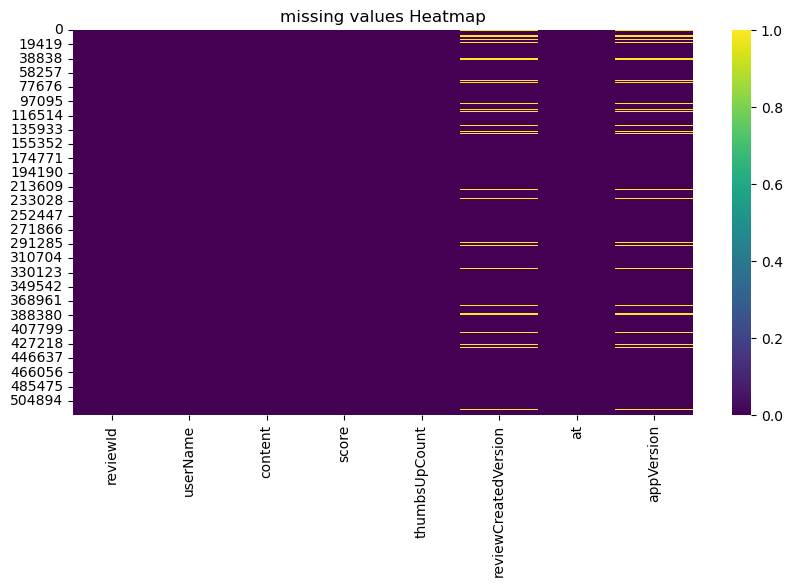

In [13]:
plt.figure(figsize=(10,5))
sns.heatmap( df_sample.isnull(),
            
            cmap="viridis")
plt.title("missing values Heatmap")
plt.show()

### find dupliactes

In [14]:
df_sample.duplicated().sum()

np.int64(805)

In [15]:
sample_df =df_sample.drop_duplicates()

In [16]:
sample_df.shape

(523483, 8)

In [17]:
sample_df.dtypes

reviewId                object
userName                object
content                 object
score                    int64
thumbsUpCount            int64
reviewCreatedVersion    object
at                      object
appVersion              object
dtype: object

In [18]:
#sample_df["at"] = pd.to_datetime(sample_df["at"])
##dateformat maybe have of anytype so first cheack the sample dattime 
sample_df["at"].head(10)

0    09-01-2025 14:55
1    29-07-2024 09:20
2    31-08-2024 11:27
3    07-01-2025 14:21
4    03-04-2025 12:39
5    10-10-2025 06:27
6    25-08-2025 10:41
7    03-02-2025 14:15
8    16-08-2025 09:04
9    24-06-2026 05:03
Name: at, dtype: object

In [19]:
# converting dt of string to the datetime format
sample_df["at"] = pd.to_datetime(
    sample_df["at"],
    format="%d-%m-%Y %H:%M"
)

In [20]:
sample_df.info() # now you can see the chnageed Dtype of dt

<class 'pandas.core.frame.DataFrame'>
Index: 523483 entries, 0 to 524287
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              523483 non-null  object        
 1   userName              523482 non-null  object        
 2   content               523475 non-null  object        
 3   score                 523483 non-null  int64         
 4   thumbsUpCount         523483 non-null  int64         
 5   reviewCreatedVersion  487257 non-null  object        
 6   at                    523483 non-null  datetime64[ns]
 7   appVersion            487257 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 35.9+ MB


### finding uniques values

In [21]:
sample_df.nunique().sort_values()

score                        5
reviewCreatedVersion       168
appVersion                 168
thumbsUpCount              213
content                 263863
at                      311155
userName                453350
reviewId                521439
dtype: int64

In [22]:
# Create data Quality Report 
quality_report = pd.DataFrame({

    "Data Type": sample_df.dtypes,

    "Missing": sample_df.isnull().sum(),

    "Unique Values": sample_df.nunique(),

    "Duplicate": sample_df.duplicated().sum()

})

quality_report

,Data Type,Missing,Unique Values,Duplicate
reviewId,object,0,521439,0
userName,object,1,453350,0
content,object,8,263863,0
score,int64,0,5,0
thumbsUpCount,int64,0,213,0
reviewCreatedVersion,object,36226,168,0
at,datetime64[ns],0,311155,0
appVersion,object,36226,168,0


## handling missing values 

In [23]:
sample_df["userName"] = sample_df["userName"].fillna("Unknown User")

In [24]:
sample_df["content"] = sample_df["content"].fillna("No Review")

In [25]:
sample_df["reviewCreatedVersion"].value_counts().head(10)

reviewCreatedVersion
1.2025.084    21642
1.2026.125    13861
1.2025.154    12753
1.2024.352    12742
1.2025.091    10869
1.2025.350    10262
1.2025.105    10076
1.2025.175     9332
1.2024.268     8343
1.2025.203     8237
Name: count, dtype: int64

In [26]:
sample_df["reviewCreatedVersion"].fillna(
    sample_df["reviewCreatedVersion"].mode()[0],
    inplace=True
)

In [27]:
sample_df["appVersion"].fillna(
    sample_df["appVersion"].mode()[0],
    inplace=True
)

In [28]:
sample_df.isnull().sum()

reviewId                0
userName                0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
appVersion              0
dtype: int64